# Test generated ONNX model

In [1]:
import onnxruntime as ort
import numpy as np
import torch
from diffusers import DDPMScheduler
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [ ]:
SNAPSHOT_PATH = "output/snapshots"
EPOCH_TO_TEST = 100
UNET_ONNX_PATH = f"{SNAPSHOT_PATH}/model_epoch_{EPOCH_TO_TEST}.onnx"
VAE_ONNX_PATH = f"{SNAPSHOT_PATH}/vae_decoder.onnx"

print(f"Testing ONNX models:\n UNet: {UNET_ONNX_PATH}\n VAE:  {VAE_ONNX_PATH}")

Testing ONNX models:
 UNet: output/snapshots/model_epoch_70.onnx
 VAE:  output/snapshots/vae_decoder.onnx


In [ ]:
# Load models
unet_session = ort.InferenceSession(UNET_ONNX_PATH)
vae_session = ort.InferenceSession(VAE_ONNX_PATH)

2025-12-20 10:30:24.164 python[45771:3248039] 2025-12-20 10:30:24.164290 [W:onnxruntime:, coreml_execution_provider.cc:113 GetCapability] CoreMLExecutionProvider::GetCapability, number of partitions supported by CoreML: 102 number of nodes in the graph: 920 number of nodes supported by CoreML: 536
2025-12-20 10:30:28.180 python[45771:3248039] 2025-12-20 10:30:28.179990 [W:onnxruntime:, coreml_execution_provider.cc:113 GetCapability] CoreMLExecutionProvider::GetCapability, number of partitions supported by CoreML: 39 number of nodes in the graph: 340 number of nodes supported by CoreML: 224


In [4]:
# Setup scheduler
scheduler = DDPMScheduler(num_train_timesteps=1000)

In [5]:
# 3. Sampling Loop
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
latents = np.random.randn(1, 4, 64, 64).astype(np.float32)

In [6]:
for t in tqdm(scheduler.timesteps):
    # Prepare inputs for ONNX
    # NOTE: DDPMScheduler timesteps are tensors, we need numpy int64 or float32 depending on export
    # Standard export usually expects int64
    t_input = np.array([t], dtype=np.int64)

    # --- RUN UNET (ONNX) ---
    # Inputs must match the names used during export: "sample" and "timestep"
    unet_inputs = {
        "sample": latents,
        "timestep": t_input
    }
    
    # Run inference
    # Output name matches export: "noise_pred"
    unet_outs = unet_session.run(["noise_pred"], unet_inputs)
    noise_pred = unet_outs[0] # This is a numpy array

    # --- SCHEDULER STEP (Helper) ---
    # We temporarily convert to Torch to let the library handle the complex 
    # alpha/beta math, effectively isolating the ONNX model test.
    noise_pred_torch = torch.from_numpy(noise_pred)
    latents_torch = torch.from_numpy(latents)
    
    # Apply one step of denoising
    # Note: verify if your scheduler expects 'step' or custom logic
    new_latents = scheduler.step(noise_pred_torch, t, latents_torch).prev_sample
    
    # Convert back to Numpy for next loop
    latents = new_latents.numpy()

  0%|          | 0/1000 [00:00<?, ?it/s]

Context leak detected, msgtracer returned -1
Context leak detected, msgtracer returned -1


In [9]:
# Decode latents with VAE (ONNX)
latents_scaled = latents * (1 / 0.18215)
vae_inputs = { "latent_sample": latents_scaled }
vae_outs = vae_session.run(["sample"], vae_inputs)
image_numpy = vae_outs[0] # Shape: (1, 3, 512, 512)

Context leak detected, msgtracer returned -1
Context leak detected, msgtracer returned -1


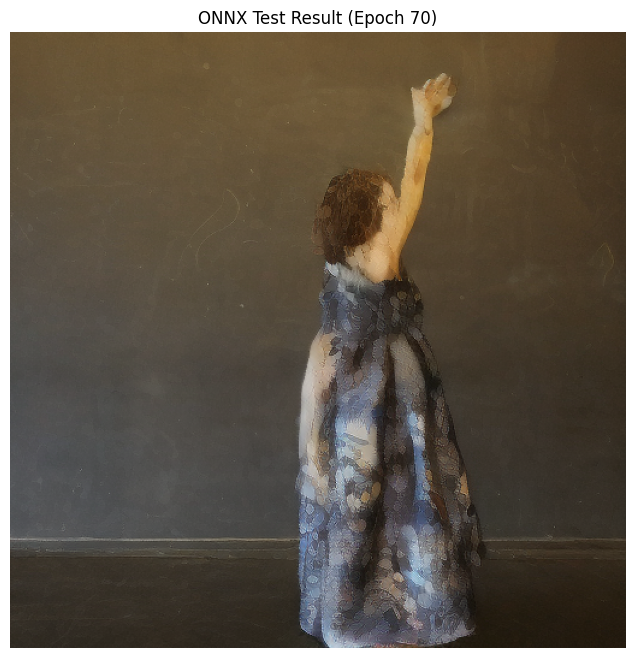

In [10]:
image_show = image_numpy[0].transpose(1, 2, 0) # CHW -> HWC
image_show = (image_show / 2 + 0.5).clip(0, 1)
plt.figure(figsize=(8, 8))
plt.imshow(image_show)
plt.axis("off")
plt.title(f"ONNX Test Result (Epoch {EPOCH_TO_TEST})")
plt.show()